# Tech Challenge 3 - Análise Exploratória de Dados (EDA)

**Aluno:** Gustavo Soriano Leandro | **RM:** 368023

Este notebook realiza uma análise exploratória completa dos datasets de voos domésticos dos EUA em 2015.  

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

---
## 1. Carregamento dos dados

In [26]:
flights = pd.read_csv('data/flights.csv')
airlines = pd.read_csv('data/airlines.csv')
airports = pd.read_csv('data/airports.csv')

print(f'Arquivo airlines : {airlines.shape[0]} linhas × {airlines.shape[1]} colunas')
print(f'Arquivo airports : {airports.shape[0]} linhas × {airports.shape[1]} colunas')
print(f'Arquivo flights : {flights.shape[0]} linhas × {flights.shape[1]} colunas')

/var/folders/zj/p_9n_6j945n_pxm9m8dhdjhr0000gn/T/ipykernel_7251/155678422.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('data/flights.csv')


Arquivo airlines : 14 linhas × 2 colunas
Arquivo airports : 322 linhas × 7 colunas
Arquivo flights : 5819079 linhas × 31 colunas


---
## 2. Visão geral do schema

In [27]:
# Exibindo as primeiras linhas do dataframe airlines
airlines.head(5)

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [28]:
# Exibindo as primeiras linhas do dataframe airports
airports.head(5)

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [29]:
# Exibindo as primeiras linhas do dataframe flights
flights.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Exibindo mais informações sobre o dataframe flights
flights.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 5819079 non-null  int64  
 1   MONTH                5819079 non-null  int64  
 2   DAY                  5819079 non-null  int64  
 3   DAY_OF_WEEK          5819079 non-null  int64  
 4   AIRLINE              5819079 non-null  str    
 5   FLIGHT_NUMBER        5819079 non-null  int64  
 6   TAIL_NUMBER          5804358 non-null  str    
 7   ORIGIN_AIRPORT       5819079 non-null  object 
 8   DESTINATION_AIRPORT  5819079 non-null  object 
 9   SCHEDULED_DEPARTURE  5819079 non-null  int64  
 10  DEPARTURE_TIME       5732926 non-null  float64
 11  DEPARTURE_DELAY      5732926 non-null  float64
 12  TAXI_OUT             5730032 non-null  float64
 13  WHEELS_OFF           5730032 non-null  float64
 14  SCHEDULED_TIME       5819073 non-null  float64
 15  ELAPSED_T

---
## 3. Estatísticas descritivas - dataframe flights

In [31]:
numeric_cols = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE',
    'AIR_TIME', 'ELAPSED_TIME', 'SCHEDULED_TIME',
    'TAXI_OUT', 'TAXI_IN',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

stats = flights[numeric_cols].describe().T
stats['missing_%'] = (flights[numeric_cols].isna().sum() / len(flights) * 100).round(2)
stats.style.format('{:.2f}').background_gradient(subset=['missing_%'], cmap='Reds')

,count,mean,std,min,25%,50%,75%,max,missing_%
DEPARTURE_DELAY,5732926.00,9.37,37.08,-82.00,-5.00,-2.00,7.00,1988.00,1.48
ARRIVAL_DELAY,5714008.00,4.41,39.27,-87.00,-13.00,-5.00,8.00,1971.00,1.81
DISTANCE,5819079.00,822.36,607.78,21.00,373.00,647.00,1062.00,4983.00,0.00
AIR_TIME,5714008.00,113.51,72.23,7.00,60.00,94.00,144.00,690.00,1.81
ELAPSED_TIME,5714008.00,137.01,74.21,14.00,82.00,118.00,168.00,766.00,1.81
SCHEDULED_TIME,5819073.00,141.69,75.21,18.00,85.00,123.00,173.00,718.00,0.00
TAXI_OUT,5730032.00,16.07,8.90,1.00,11.00,14.00,19.00,225.00,1.53
TAXI_IN,5726566.00,7.43,5.64,1.00,4.00,6.00,9.00,248.00,1.59
AIR_SYSTEM_DELAY,1063439.00,13.48,28.00,0.00,0.00,2.00,18.00,1134.00,81.72
SECURITY_DELAY,1063439.00,0.08,2.14,0.00,0.00,0.00,0.00,573.00,81.72


In [32]:
# Percentual de voos cancelados e desviados
total = len(flights)
cancelled_pct = flights['CANCELLED'].sum() / total * 100
diverted_pct  = flights['DIVERTED'].sum()  / total * 100

print(f'Voos cancelados : {flights["CANCELLED"].sum():,} ({cancelled_pct:.2f}%)')
print(f'Voos desviados  : {flights["DIVERTED"].sum():,}  ({diverted_pct:.2f}%)')

Voos cancelados : 89,884 (1.54%)
Voos desviados  : 15,187  (0.26%)


---
## 4. Análise e tratamento de valores ausentes

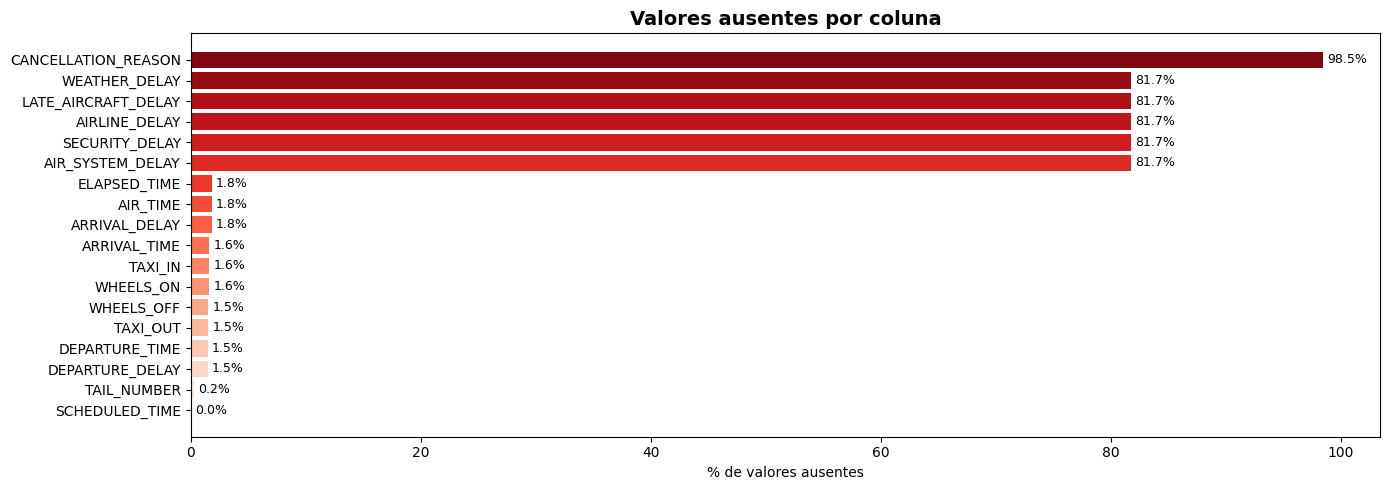

In [33]:
missing = flights.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / total * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(missing.index, missing_pct.values, color=sns.color_palette('Reds_r', len(missing)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de valores ausentes')
ax.set_title('Valores ausentes por coluna', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Estratégia de tratamento de valores ausentes

Colunas de delay (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`)
- Motivo do nulo: Voo **não teve** atraso registrado
- Tratamento: Preenche com `0`

Coluna de cancelamento (`CANCELLATION_REASON`)
- Motivo do nulo: Voo **não foi** cancelado
- Tratamento: Preenche com `N/A`

Colunas operacioanis (`DEPARTURE_TIME`, `ARRIVAL_TIME`, `TAXI_OUT`, `TAXI_IN`, `WHEELS_OFF`, `WHEELS_ON`, `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `ELAPSED_TIME`, `AIR_TIME`)
- Motivo do nulo: Voo **cancelado ou desviado**
- Tratamento: Mantém como `NaN` — será filtrado por `CANCELLED == 0` quando necessário

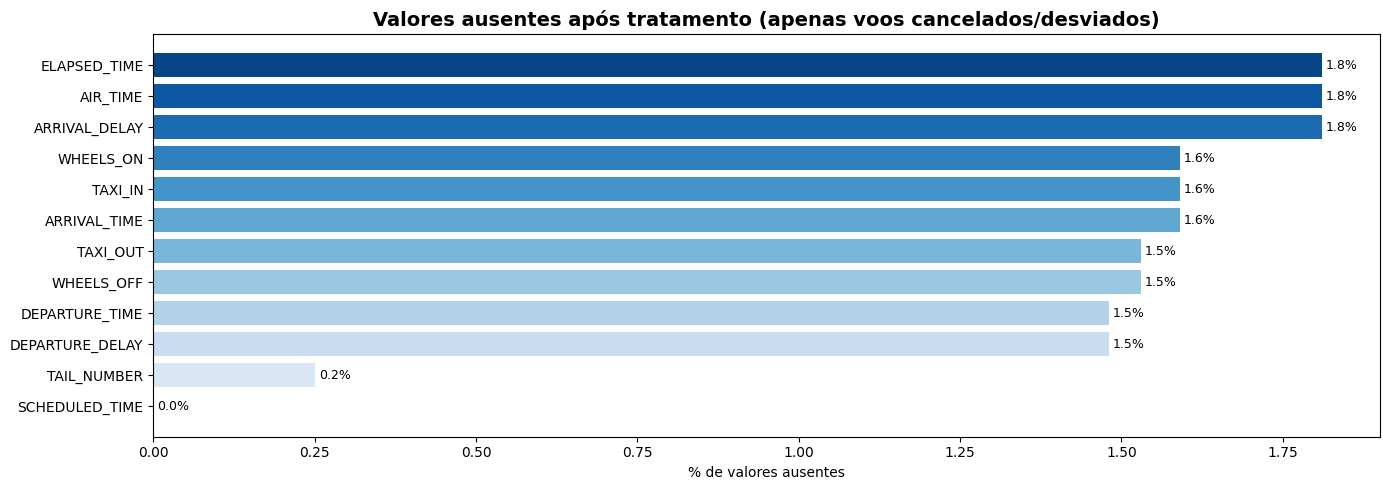

In [34]:
delay_cols = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]
flights[delay_cols] = flights[delay_cols].fillna(0)
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('N/A')

missing_after = flights.isna().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
missing_after_pct = (missing_after / len(flights) * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(missing_after.index, missing_after_pct.values, color=sns.color_palette('Blues_r', len(missing_after)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de valores ausentes')
ax.set_title('Valores ausentes após tratamento (apenas voos cancelados/desviados)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
# Dataset de voos que efetivamente pousaram (não cancelados)
completed = flights[flights['CANCELLED'] == 0].copy()
print(f'Total de voos    : {len(flights):,}')
print(f'Voos concluídos  : {len(completed):,} ({len(completed) / len(flights) * 100:.2f}%)')

Total de voos    : 5,819,079
Voos concluídos  : 5,729,195 (98.46%)


---
## 5. Distribuição de atrasos

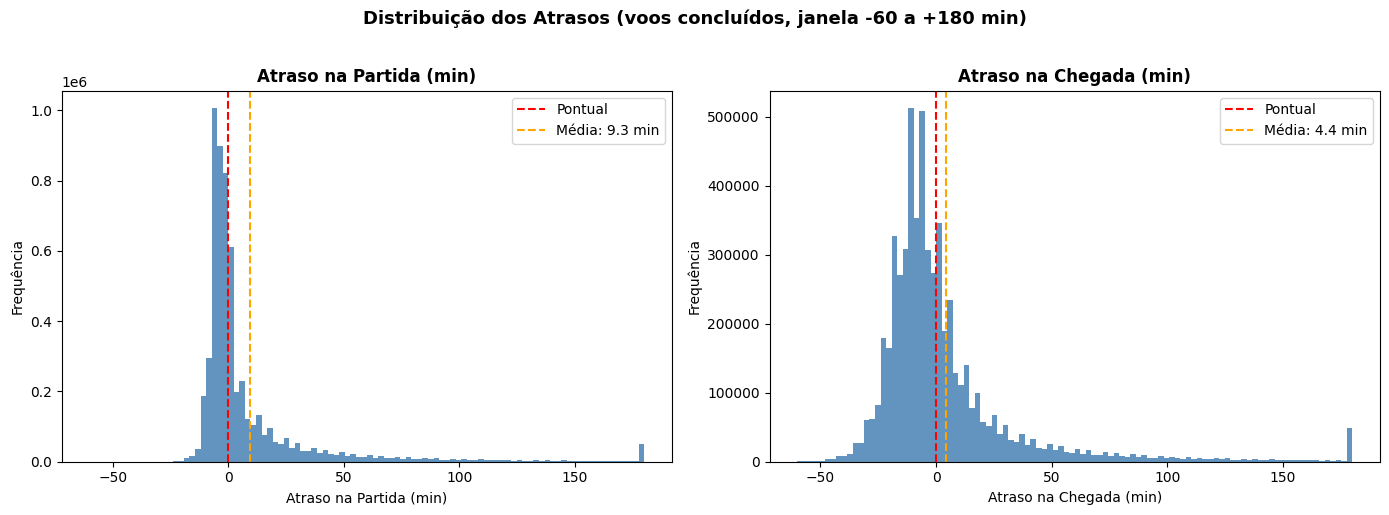

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'],
    ['Atraso na Partida (min)', 'Atraso na Chegada (min)']
):
    data = completed[col].dropna()
    # Foco na faixa -60 a +180 min para melhor visualização
    data_clipped = data.clip(-60, 180)
    ax.hist(data_clipped, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(0, color='red', lw=1.5, linestyle='--', label='Pontual')
    ax.axvline(data.mean(), color='orange', lw=1.5, linestyle='--',
               label=f'Média: {data.mean():.1f} min')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Distribuição dos Atrasos (voos concluídos, janela -60 a +180 min)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observações - Histograma de atrasos:**
- A distribuição é **assimétrica à direita** (*right-skewed*): a maioria dos voos parte e chega no horário ou adiantada, mas uma minoria com grandes atrasos puxa a média para cima.
- A **média** fica acima do zero, enquanto o pico da distribuição se concentra antes do zero — o que indica que a média sozinha não representa bem o comportamento típico dos voos.
- Os atrasos na chegada seguem padrão similar ao da partida, o que sugere que atrasos na saída se propagam para a chegada.

/var/folders/zj/p_9n_6j945n_pxm9m8dhdjhr0000gn/T/ipykernel_7251/3081807586.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=['Atraso na Partida', 'Atraso na Chegada'],


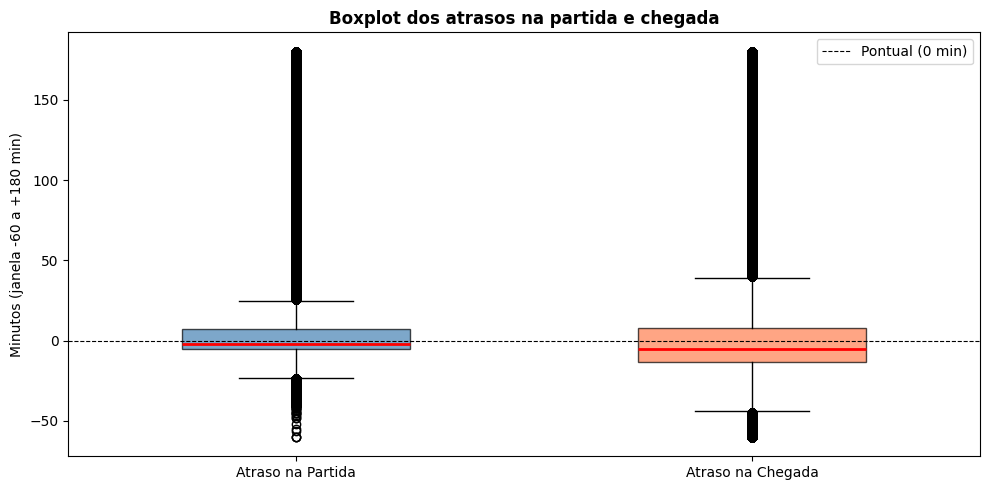

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

data_box = [
    completed['DEPARTURE_DELAY'].clip(-60, 180).dropna(),
    completed['ARRIVAL_DELAY'].clip(-60, 180).dropna()
]

bp = ax.boxplot(data_box, labels=['Atraso na Partida', 'Atraso na Chegada'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='red', linewidth=2))

colors = ['steelblue', 'coral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='black', lw=0.8, linestyle='--', label='Pontual (0 min)')
ax.set_ylabel('Minutos (janela -60 a +180 min)')
ax.set_title('Boxplot dos atrasos na partida e chegada', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observações - Boxplot:**
- A **mediana** (linha vermelha) de ambas as colunas fica próxima ou levemente abaixo de zero, confirmando que mais da metade dos voos é pontual ou adiantada.
- O **IQR** (caixa) é relativamente estreito, mas os *whiskers* e a grande quantidade de pontos acima indicam **muitos outliers de atraso severo**.
- O atraso na chegada apresenta dispersão ligeiramente maior que o da partida, sugerindo que alguns voos acumulam atraso adicional durante o voo.

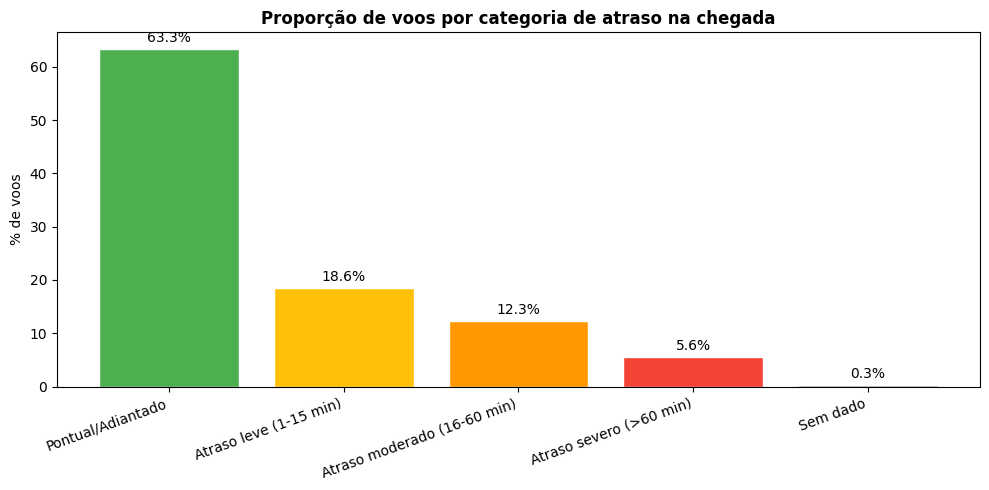

In [38]:
# Proporção de voos por categoria de atraso
def delay_category(d):
    if pd.isna(d):  return 'Sem dado'
    if d <= 0:      return 'Pontual/Adiantado'
    if d <= 15:     return 'Atraso leve (1-15 min)'
    if d <= 60:     return 'Atraso moderado (16-60 min)'
    return 'Atraso severo (>60 min)'

completed['DELAY_CAT'] = completed['ARRIVAL_DELAY'].apply(delay_category)
cat_order = ['Pontual/Adiantado', 'Atraso leve (1-15 min)',
             'Atraso moderado (16-60 min)', 'Atraso severo (>60 min)', 'Sem dado']
counts = completed['DELAY_CAT'].value_counts().reindex(cat_order).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9E9E9E']
bars = ax.bar(counts.index, counts.values / len(completed) * 100,
              color=colors[:len(counts)], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('% de voos')
ax.set_title('Proporção de voos por categoria de atraso na chegada', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**Observações - Categorias de atraso:**
- A maior parte dos voos é classificada como **pontual ou adiantada**, reforçando que o problema de atraso afeta uma parcela menor da operação.
- Os **atrasos moderados (16–60 min)** representam a segunda maior categoria, sendo o grupo mais impactante para a experiência do passageiro.
- Os **atrasos severos (>60 min)** são menos frequentes, mas têm alto impacto operacional em conexões e planejamento de frota.

---
## 6. Atrasos por companhia aérea

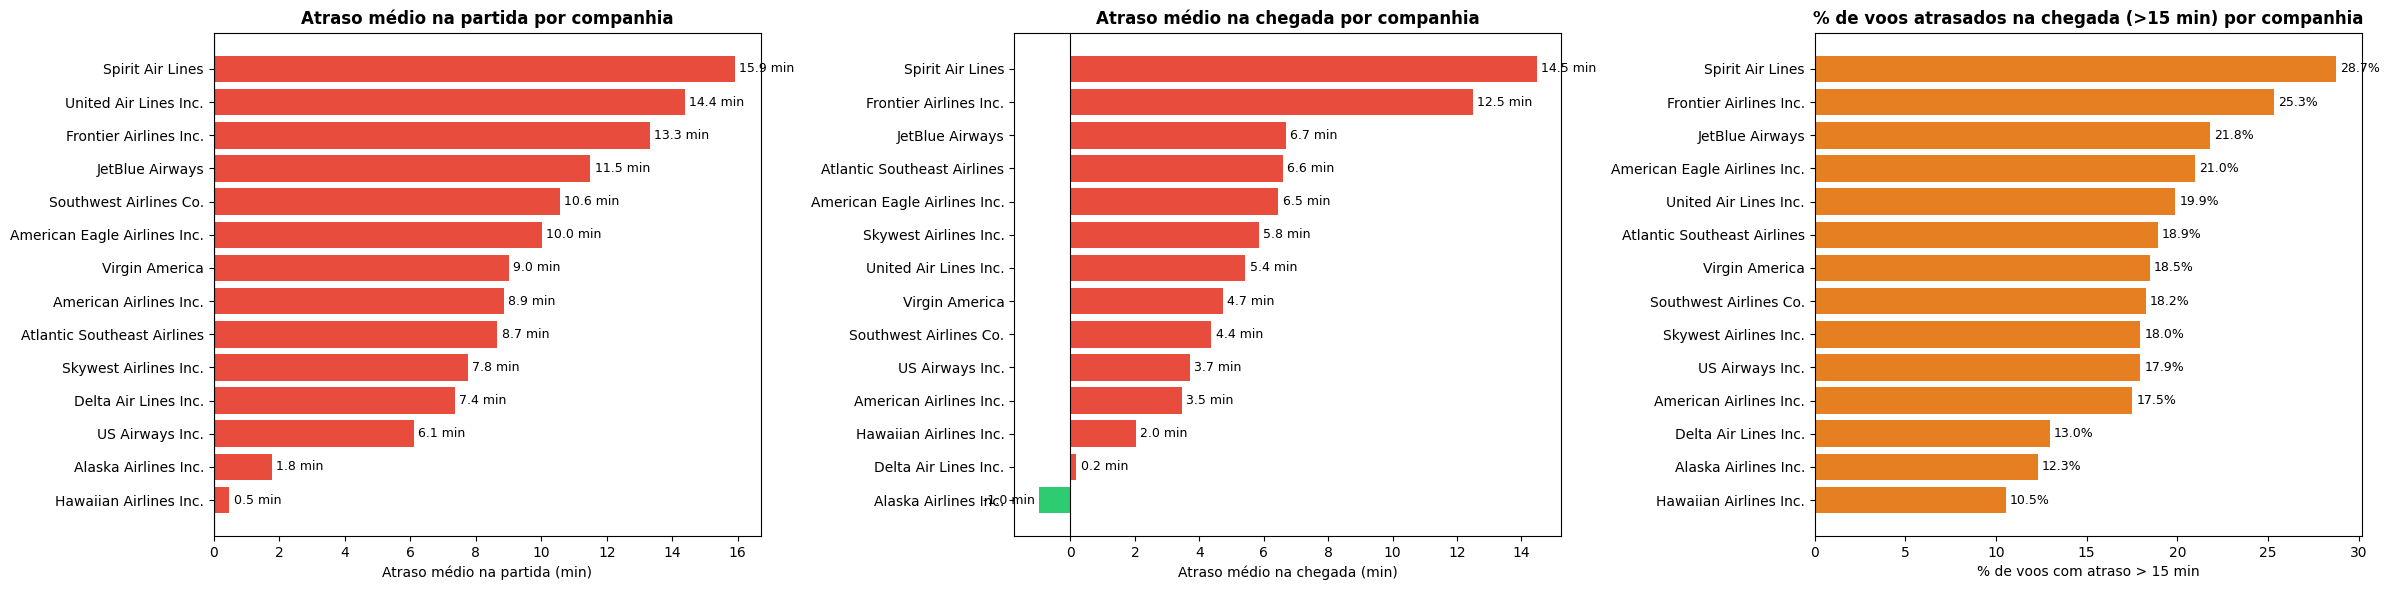

In [45]:
airline_stats = (
    completed
    .groupby('AIRLINE')
    .agg(
        total_flights=('ARRIVAL_DELAY', 'count'),
        avg_arrival_delay=('ARRIVAL_DELAY', 'mean'),
        pct_delayed=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100),
        avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
        pct_dep_delayed=('DEPARTURE_DELAY', lambda x: (x > 15).mean() * 100),
    )
    .reset_index()
    .merge(airlines, left_on='AIRLINE', right_on='IATA_CODE')
    .sort_values('avg_arrival_delay', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Atraso médio na partida
dep_sorted = airline_stats.sort_values('avg_departure_delay', ascending=False)
ax = axes[0]
palette_dep = ['#e74c3c' if v > 0 else '#2ecc71' for v in dep_sorted['avg_departure_delay']]
bars = ax.barh(dep_sorted['AIRLINE_y'], dep_sorted['avg_departure_delay'], color=palette_dep)
ax.axvline(0, color='black', lw=0.8)
ax.bar_label(bars, fmt='%.1f min', padding=3, fontsize=9)
ax.set_xlabel('Atraso médio na partida (min)')
ax.set_title('Atraso médio na partida por companhia', fontweight='bold')
ax.invert_yaxis()

# Atraso médio na chegada
ax = axes[1]
palette = ['#e74c3c' if v > 0 else '#2ecc71' for v in airline_stats['avg_arrival_delay']]
bars = ax.barh(airline_stats['AIRLINE_y'], airline_stats['avg_arrival_delay'], color=palette)
ax.axvline(0, color='black', lw=0.8)
ax.bar_label(bars, fmt='%.1f min', padding=3, fontsize=9)
ax.set_xlabel('Atraso médio na chegada (min)')
ax.set_title('Atraso médio na chegada por companhia', fontweight='bold')
ax.invert_yaxis()

# % voos com atraso na chegada > 15 min
ax = axes[2]
bars = ax.barh(airline_stats.sort_values('pct_delayed', ascending=False)['AIRLINE_y'],
               airline_stats.sort_values('pct_delayed', ascending=False)['pct_delayed'],
               color='#e67e22')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de voos com atraso > 15 min')
ax.set_title('% de voos atrasados na chegada (>15 min) por companhia', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()


**Observações - Atrasos por companhia aérea:**
- **Spirit Airlines** e **Frontier Airlines** lideram em atraso médio na chegada e na partida.
- **Alaska Airlines** e **Hawaiian Airlines** apresentam os melhores desempenhos, chegando frequentemente antes do horário previsto (valores negativos).
- A **% de voos atrasados (>15 min)** reforça o padrão: Spirit e Frontier têm quase 1 em cada 3 voos atrasados, enquanto Hawaiian mantém menos de 10%.
- Companhias tradicionais como **United** e **American** ficam na faixa intermediária, com atrasos médios entre 5 e 10 min.

---
## 7. Padrões temporais

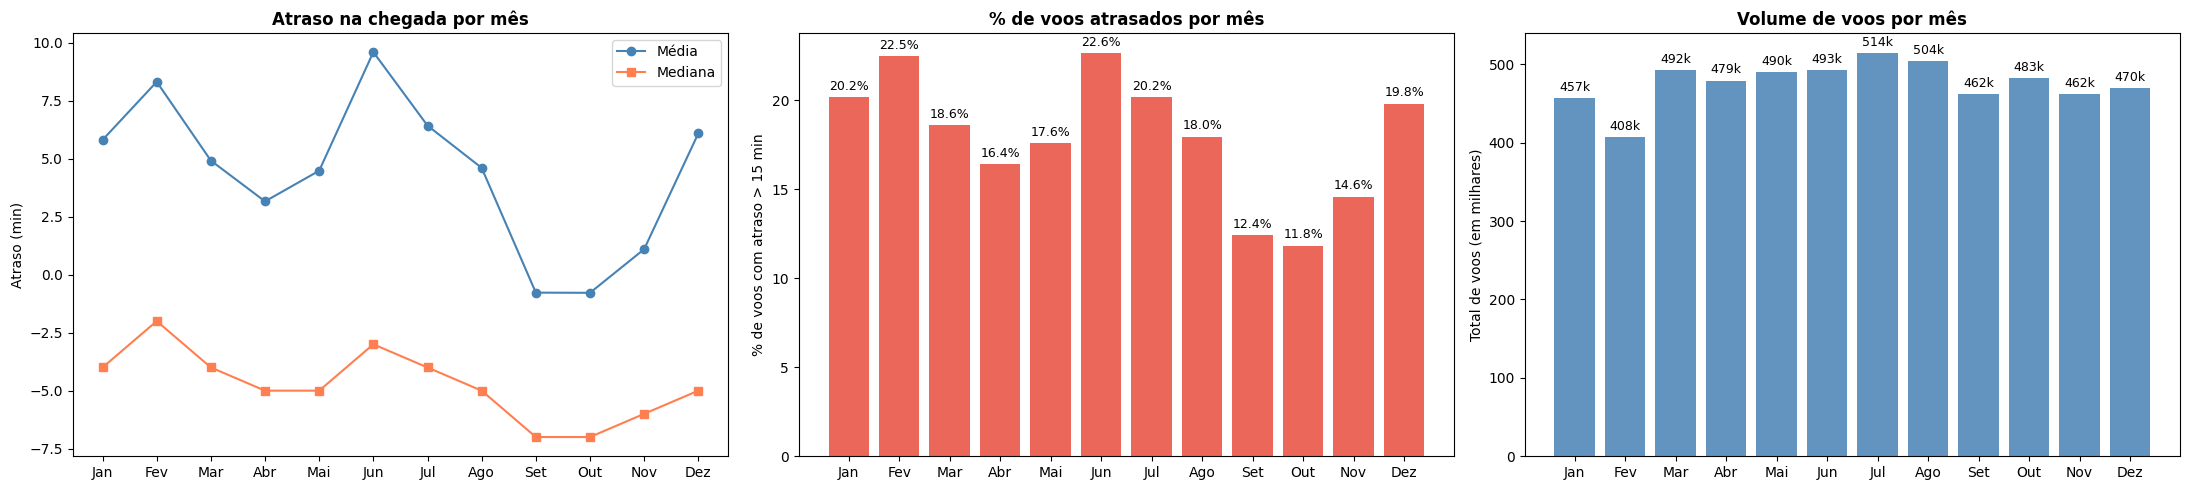

In [57]:
# Atraso médio por mês
monthly = (
    completed
    .groupby('MONTH')['ARRIVAL_DELAY']
    .agg(['mean', 'median', lambda x: (x > 15).mean() * 100, 'count'])
    .rename(columns={'mean': 'Média', 'median': 'Mediana', '<lambda_0>': '% atrasados', 'count': 'total_voos'})
)
month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

ax = axes[0]
ax.plot(monthly.index, monthly['Média'], marker='o', label='Média', color='steelblue')
ax.plot(monthly.index, monthly['Mediana'], marker='s', label='Mediana', color='coral')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Atraso (min)')
ax.set_title('Atraso na chegada por mês', fontweight='bold')
ax.legend()

ax = axes[1]
bars = ax.bar(monthly.index, monthly['% atrasados'], color='#e74c3c', alpha=0.85)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('% de voos com atraso > 15 min')
ax.set_title('% de voos atrasados por mês', fontweight='bold')

ax = axes[2]
bars = ax.bar(monthly.index, monthly['total_voos'] / 1000, color='steelblue', alpha=0.85)
ax.bar_label(bars, fmt='%.0fk', padding=3, fontsize=9)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Total de voos (em milhares)')
ax.set_title('Volume de voos por mês', fontweight='bold')

plt.tight_layout()
plt.show()


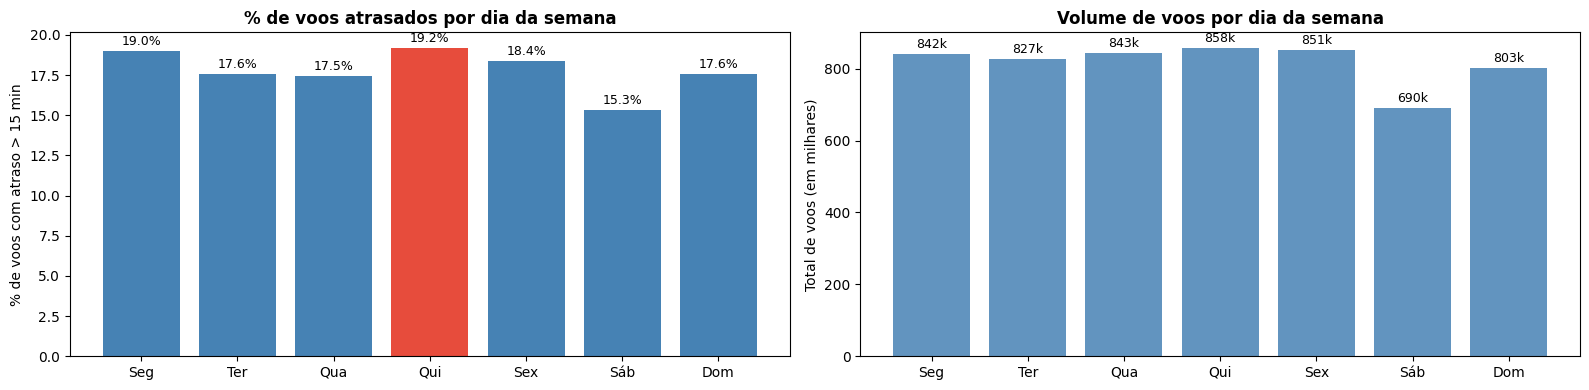

In [58]:
# % de voos atrasados por dia da semana
dow_names = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
dow = (
    completed
    .groupby('DAY_OF_WEEK')['ARRIVAL_DELAY']
    .agg(pct_delayed=lambda x: (x > 15).mean() * 100, total_voos='count')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
bars = ax.bar(dow.index, dow['pct_delayed'],
              color=['#e74c3c' if v == dow['pct_delayed'].max() else 'steelblue' for v in dow['pct_delayed']])
ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=9)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(dow_names)
ax.set_ylabel('% de voos com atraso > 15 min')
ax.set_title('% de voos atrasados por dia da semana', fontweight='bold')

ax = axes[1]
bars = ax.bar(dow.index, dow['total_voos'] / 1000, color='steelblue', alpha=0.85)
ax.bar_label(bars, fmt='%.0fk', padding=2, fontsize=9)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(dow_names)
ax.set_ylabel('Total de voos (em milhares)')
ax.set_title('Volume de voos por dia da semana', fontweight='bold')

plt.tight_layout()
plt.show()


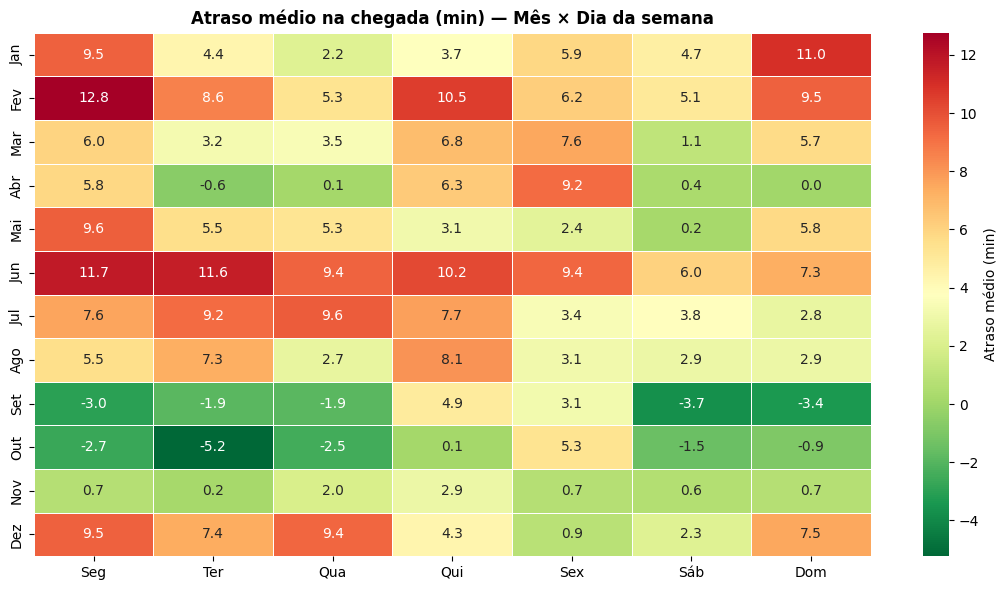

In [59]:
# Heatmap: mês × dia da semana
pivot = (
    completed
    .groupby(['MONTH', 'DAY_OF_WEEK'])['ARRIVAL_DELAY']
    .mean()
    .unstack()
)
pivot.columns = dow_names
pivot.index = month_names

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Atraso médio (min)'})
ax.set_title('Atraso médio na chegada (min) — Mês × Dia da semana', fontweight='bold')
plt.tight_layout()
plt.show()

**Observações - Padrões temporais:**
- **Junho (22.6%) e Fevereiro (22.5%)** lideram em % de voos atrasados. Junho pelo pico de demanda do verão americano, fevereiro possivelmente por condições climáticas adversas no inverno.
- **Outubro (11.8%) e Setembro (12.4%)** são os meses com menor índice de atraso, com quase metade da taxa registrada em junho.
- **Dezembro (19.8%)** apresenta percentual relevante mas não figura entre os piores meses. O impacto das festas de fim de ano é menor do que se poderia esperar.
- **Quinta-feira (19.2%) e segunda-feira (19.0%)** são os dias com maior % de atrasos. Vemos uma correlação entre volume de vôos com quantidade de atrasos por dia  de semana.
- O heatmap confirma que **junho/fevereiro combinados com quinta e segunda** concentram as piores combinações, enquanto **setembro/outubro aos sábados** representam o menor risco de atraso.

---
## 8. Causas dos atrasos

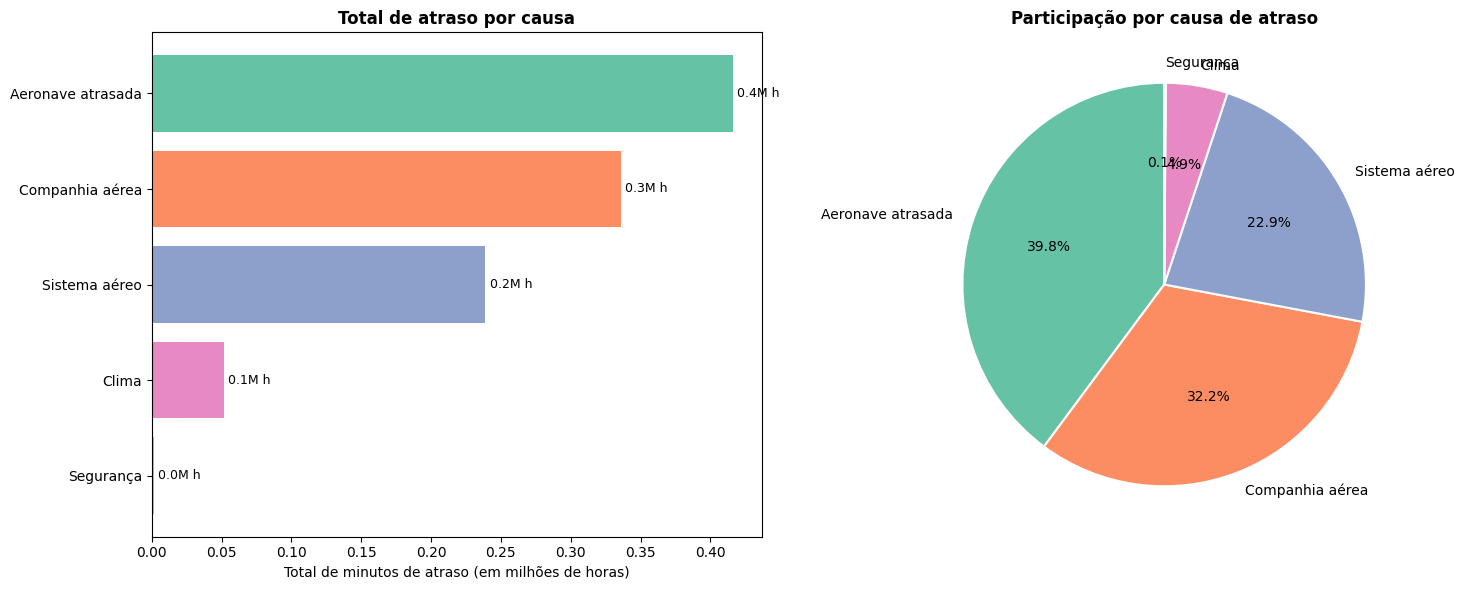

Voos com atraso registrado: 1,063,439 (18.6% dos voos concluídos)


In [60]:
delay_cause_cols = [
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]
cause_labels = [
    'Sistema aéreo', 'Segurança',
    'Companhia aérea', 'Aeronave atrasada', 'Clima'
]

# Apenas voos que tiveram algum atraso registrado
delayed_only = completed[completed[delay_cause_cols].sum(axis=1) > 0]
cause_totals = delayed_only[delay_cause_cols].sum()
cause_totals.index = cause_labels
cause_totals = cause_totals.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barras
ax = axes[0]
colors = sns.color_palette('Set2', len(cause_totals))
bars = ax.barh(cause_totals.index, cause_totals.values / 60 / 1e6, color=colors)
ax.bar_label(bars, fmt='%.1fM h', padding=3, fontsize=9)
ax.set_xlabel('Total de minutos de atraso (em milhões de horas)')
ax.set_title('Total de atraso por causa', fontweight='bold')
ax.invert_yaxis()

# Pizza
ax = axes[1]
ax.pie(cause_totals.values, labels=cause_totals.index,
       autopct='%1.1f%%', colors=colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Participação por causa de atraso', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Voos com atraso registrado: {len(delayed_only):,} ({len(delayed_only)/len(completed)*100:.1f}% dos voos concluídos)')

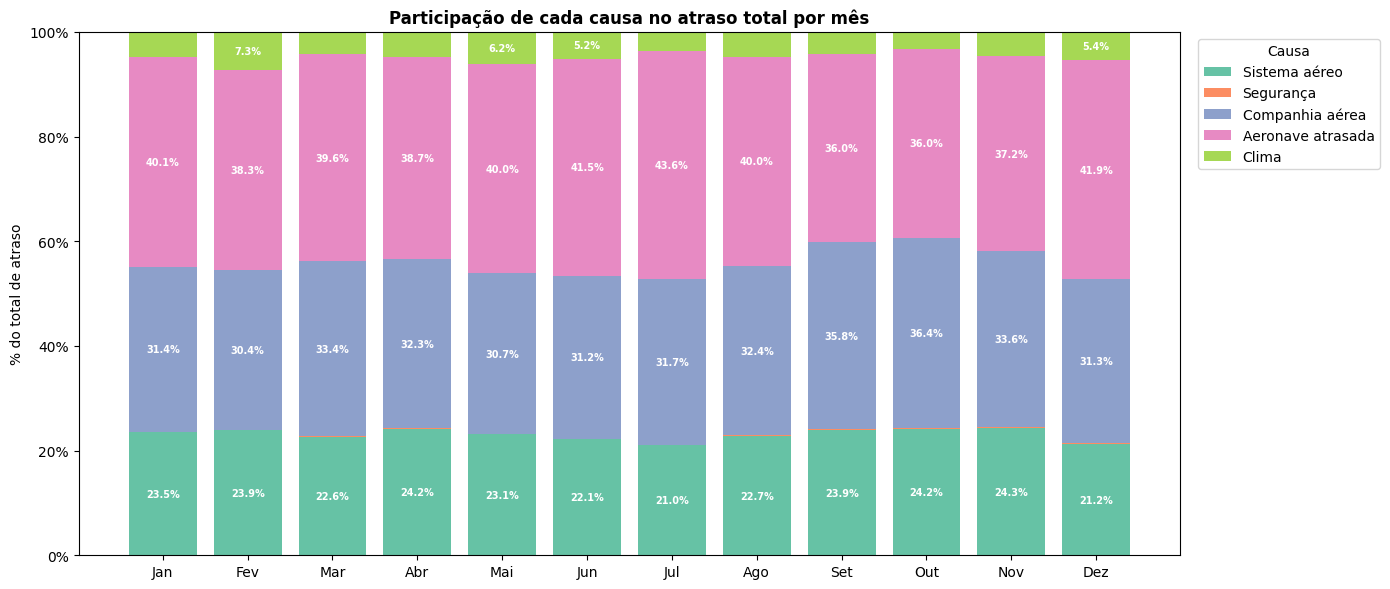

In [63]:
# % de atraso por causa por mês
cause_by_month = (
    delayed_only
    .groupby('MONTH')[delay_cause_cols]
    .sum()
    .rename(columns=dict(zip(delay_cause_cols, cause_labels)))
)
cause_by_month.index = month_names
cause_pct = cause_by_month.div(cause_by_month.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('Set2', len(cause_labels))
bottom = pd.Series([0.0] * 12, index=cause_pct.index)

for col, color in zip(cause_labels, colors):
    values = cause_pct[col]
    bars = ax.bar(cause_pct.index, values, bottom=bottom, label=col, color=color)
    for bar, val, bot in zip(bars, values, bottom):
        if val >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                f"{val:.1f}%",
                ha="center", va="center", fontsize=7, fontweight="bold", color="white"
            )
    bottom += values

ax.set_ylabel("% do total de atraso")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Participação de cada causa no atraso total por mês", fontweight="bold")
ax.legend(title="Causa", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observações - Causas dos atrasos por mês:**

- **Aeronave atrasada** atinge seu pico em **julho (43.6%) e dezembro (41.9%)** nos meses de alta demanda. Provavelmente pelo efeito cascata de atrasos devido ao maior numero de vôos.
- **Clima** responde por apenas 3–7% do atraso total, mas tem participação mais expressiva em **fevereiro (7.3%)** e **maio (6.2%)**, ajudando a explicar parte do alto percentual de voos atrasados nesses meses conforme visto anteriormente.
- **Setembro e outubro**, que na seção 7 apareceram como os meses de menor % de atrasos, também mostram aqui a maior participação de **Companhia aérea (35–36%)** podendo sugerir que, quando há menos pressão no sistema, os atrasos tendem a ser de responsabilidade direta das companhias, não de fatores externos.
- **Segurança** é irrelevante em todos os meses (< 0.2%).

---
## 9. Análise de cancelamentos

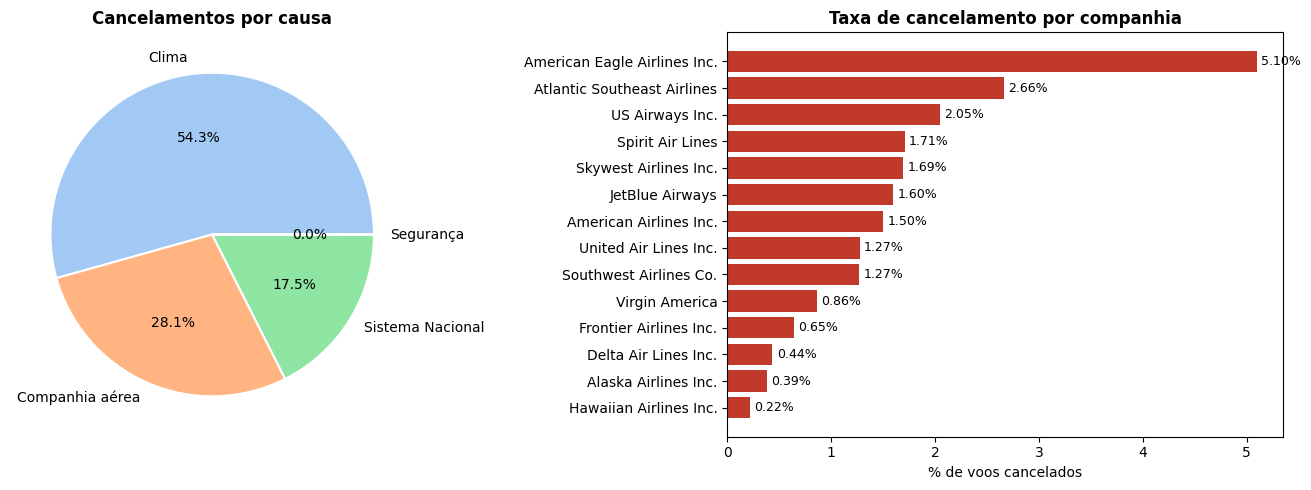

In [66]:
reason_map = {'A': 'Companhia aérea', 'B': 'Clima', 'C': 'Sistema Nacional', 'D': 'Segurança', 'N/A': 'N/A'}
cancelled_df = flights[flights['CANCELLED'] == 1].copy()
cancelled_df['REASON_LABEL'] = cancelled_df['CANCELLATION_REASON'].map(reason_map).fillna('Outro')

reason_counts = cancelled_df['REASON_LABEL'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por causa
ax = axes[0]
colors = sns.color_palette('pastel')
ax.pie(reason_counts.values, labels=reason_counts.index,
       autopct='%1.1f%%', colors=colors,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Cancelamentos por causa', fontweight='bold')

# Por companhia
cancel_by_airline = (
    flights.groupby('AIRLINE')['CANCELLED']
    .agg(['sum', 'count'])
    .assign(pct=lambda df: df['sum'] / df['count'] * 100)
    .merge(airlines, left_index=True, right_on='IATA_CODE')
    .sort_values('pct', ascending=False)
)

ax = axes[1]
bars = ax.barh(cancel_by_airline['AIRLINE'], cancel_by_airline['pct'], color='#c0392b')
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_xlabel('% de voos cancelados')
ax.set_title('Taxa de cancelamento por companhia', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

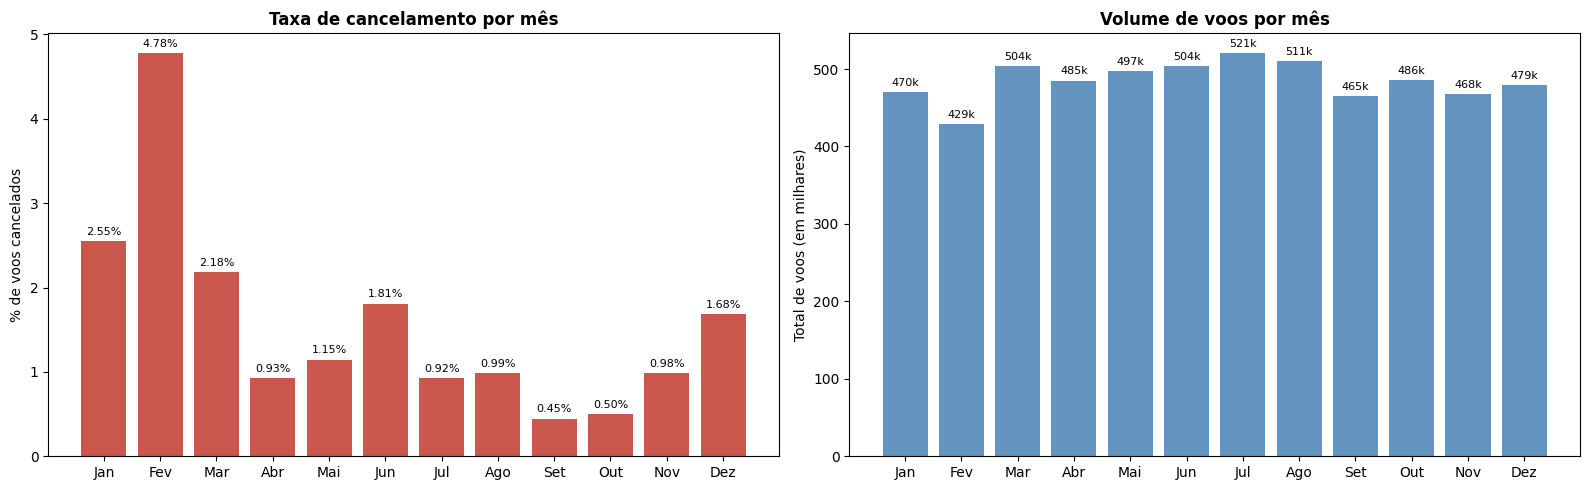

In [69]:
# % de cancelamentos por mês
cancel_month = (
    flights.groupby('MONTH')['CANCELLED']
    .agg(total='count', cancelled='sum')
    .assign(pct=lambda df: df['cancelled'] / df['total'] * 100)
)
cancel_month.index = month_names

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(cancel_month.index, cancel_month['pct'], color='#c0392b', alpha=0.85)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=8)
ax.set_ylabel('% de voos cancelados')
ax.set_title('Taxa de cancelamento por mês', fontweight='bold')

ax = axes[1]
bars = ax.bar(cancel_month.index, cancel_month['total'] / 1000, color='steelblue', alpha=0.85)
ax.bar_label(bars, fmt='%.0fk', padding=3, fontsize=8)
ax.set_ylabel('Total de voos (em milhares)')
ax.set_title('Volume de voos por mês', fontweight='bold')

plt.tight_layout()
plt.show()


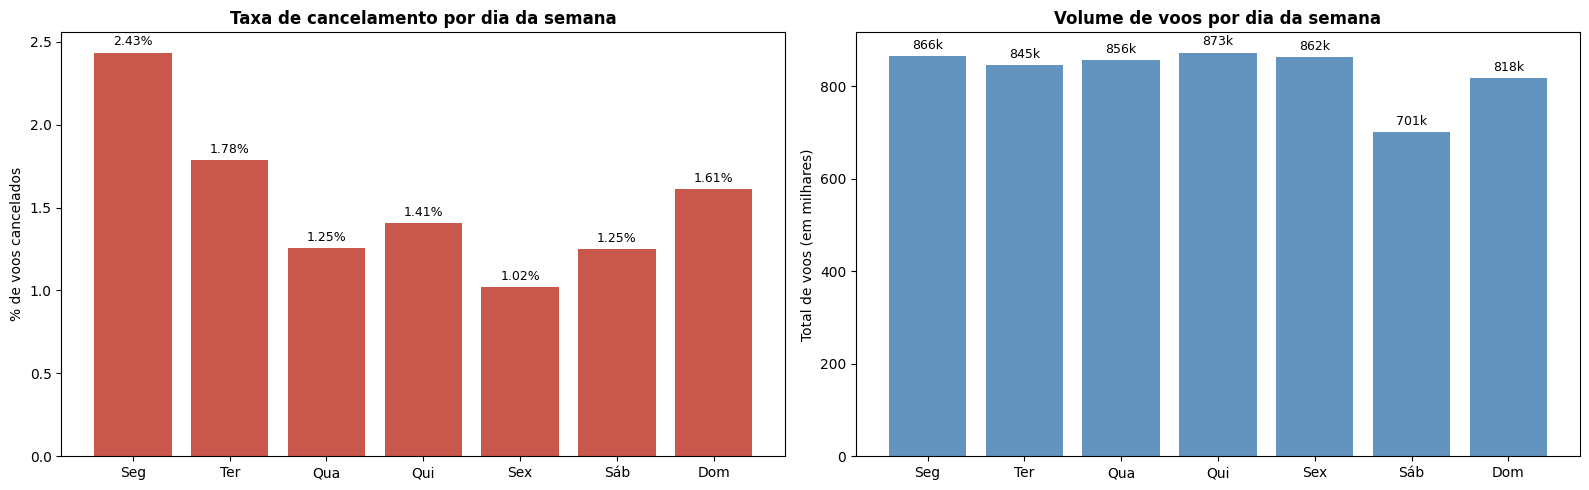

In [70]:
# % de cancelamentos por dia da semana
cancel_dow = (
    flights.groupby('DAY_OF_WEEK')['CANCELLED']
    .agg(total='count', cancelled='sum')
    .assign(pct=lambda df: df['cancelled'] / df['total'] * 100)
)
cancel_dow.index = dow_names

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(cancel_dow.index, cancel_dow['pct'], color='#c0392b', alpha=0.85)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_ylabel('% de voos cancelados')
ax.set_title('Taxa de cancelamento por dia da semana', fontweight='bold')

ax = axes[1]
bars = ax.bar(cancel_dow.index, cancel_dow['total'] / 1000, color='steelblue', alpha=0.85)
ax.bar_label(bars, fmt='%.0fk', padding=3, fontsize=9)
ax.set_ylabel('Total de voos (em milhares)')
ax.set_title('Volume de voos por dia da semana', fontweight='bold')

plt.tight_layout()
plt.show()


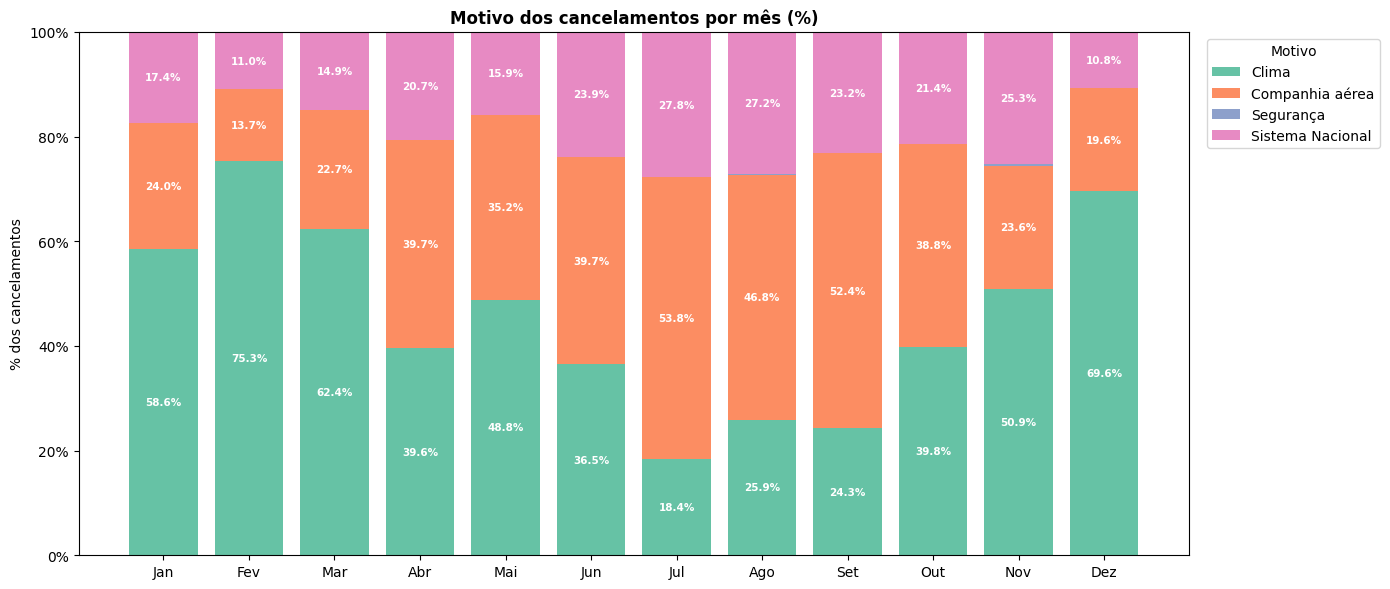

In [71]:
# % de cada motivo de cancelamento por mês (barras empilhadas 100%)
by_month_reason = (
    cancelled_df.groupby('MONTH')['REASON_LABEL']
    .value_counts()
    .unstack(fill_value=0)
)
by_month_reason_pct = by_month_reason.div(by_month_reason.sum(axis=1), axis=0) * 100
by_month_reason_pct.index = month_names

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('Set2', len(by_month_reason_pct.columns))
bottom = pd.Series([0.0] * 12, index=by_month_reason_pct.index)

for col, color in zip(by_month_reason_pct.columns, colors):
    values = by_month_reason_pct[col]
    bars = ax.bar(by_month_reason_pct.index, values, bottom=bottom, label=col, color=color)
    for bar, val, bot in zip(bars, values, bottom):
        if val >= 6:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bot + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7.5, fontweight='bold', color='white'
            )
    bottom += values

ax.set_ylabel('% dos cancelamentos')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Motivo dos cancelamentos por mês (%)', fontweight='bold')
ax.legend(title='Motivo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observações - Análise de cancelamentos:**

**Por mês:**
- **Fevereiro** tem a maior taxa de cancelamento (4.78%) com o **menor volume do ano (429k voos)** - ou seja, não é sobrecarga da malha e sim uma questão climática (75.3% dos cancelamentos de fevereiro são por clima).
- **Janeiro (2.55%)** é o segundo pior mês, também com forte componente climático (58.6%).
- **Julho** é o mês com **maior volume (520k voos)** e taxa de cancelamento baixa (0.92%). A pressão do verão se manifesta em atrasos (seção 7), não em cancelamentos. Quando há cancelamento em julho, o motivo dominante é a própria companhia aérea (53.8%).

**Por dia da semana:**
- **Segunda-feira (2.43%)** lidera os cancelamentos apesar de ter o maior volume (865k voos).
- **Sexta-feira (1.02%)** tem a menor taxa entre os dias úteis mesmo com volume elevado (862k).
- **Sábado** tem o **menor volume absoluto (700k)** e taxa moderada (1.25%). A baixa taxa de cancelamento (seção 7 também mostrou menos atrasos) reflete tanto menor demanda quanto operação mais folgada.

**Por motivo ao longo do ano:**
- O padrão de motivos divide o ano em dois regimes distintos: **inverno (nov–fev)** dominado por clima (50–75%) e **verão/outono (jun–out)** dominado por companhia aérea (39–54%) e sistema nacional (23–28%).
- **Sistema Nacional de Aviação** tem participação mais relevante nos meses de alto volume (jun–ago: ~24–28%), quando o congestionamento do espaço aéreo impõe restrições operacionais independentes do clima.
- **Segurança** é irrelevante em todos os meses (< 0.2%).

---
## 10. Aeroportos mais movimentados e com maiores atrasos

**Aeroportos não identificados:** a coluna `ORIGIN_AIRPORT` do dataset mistura dois sistemas de identificação: códigos IATA (3 letras, ex: `ATL`, `LAX`) e códigos numéricos FAA/DOT (ex: `14747`, `12889`). O arquivo `airports.csv` contém apenas códigos IATA, portanto os ~483k voos (~8% do total) com código numérico não obtiveram match no merge. Esses registros foram mantidos e classificados como **"Aeroporto não identificado" (N/ID)** pois podem corresponder a pequenos aeroportos regionais sem código IATA.

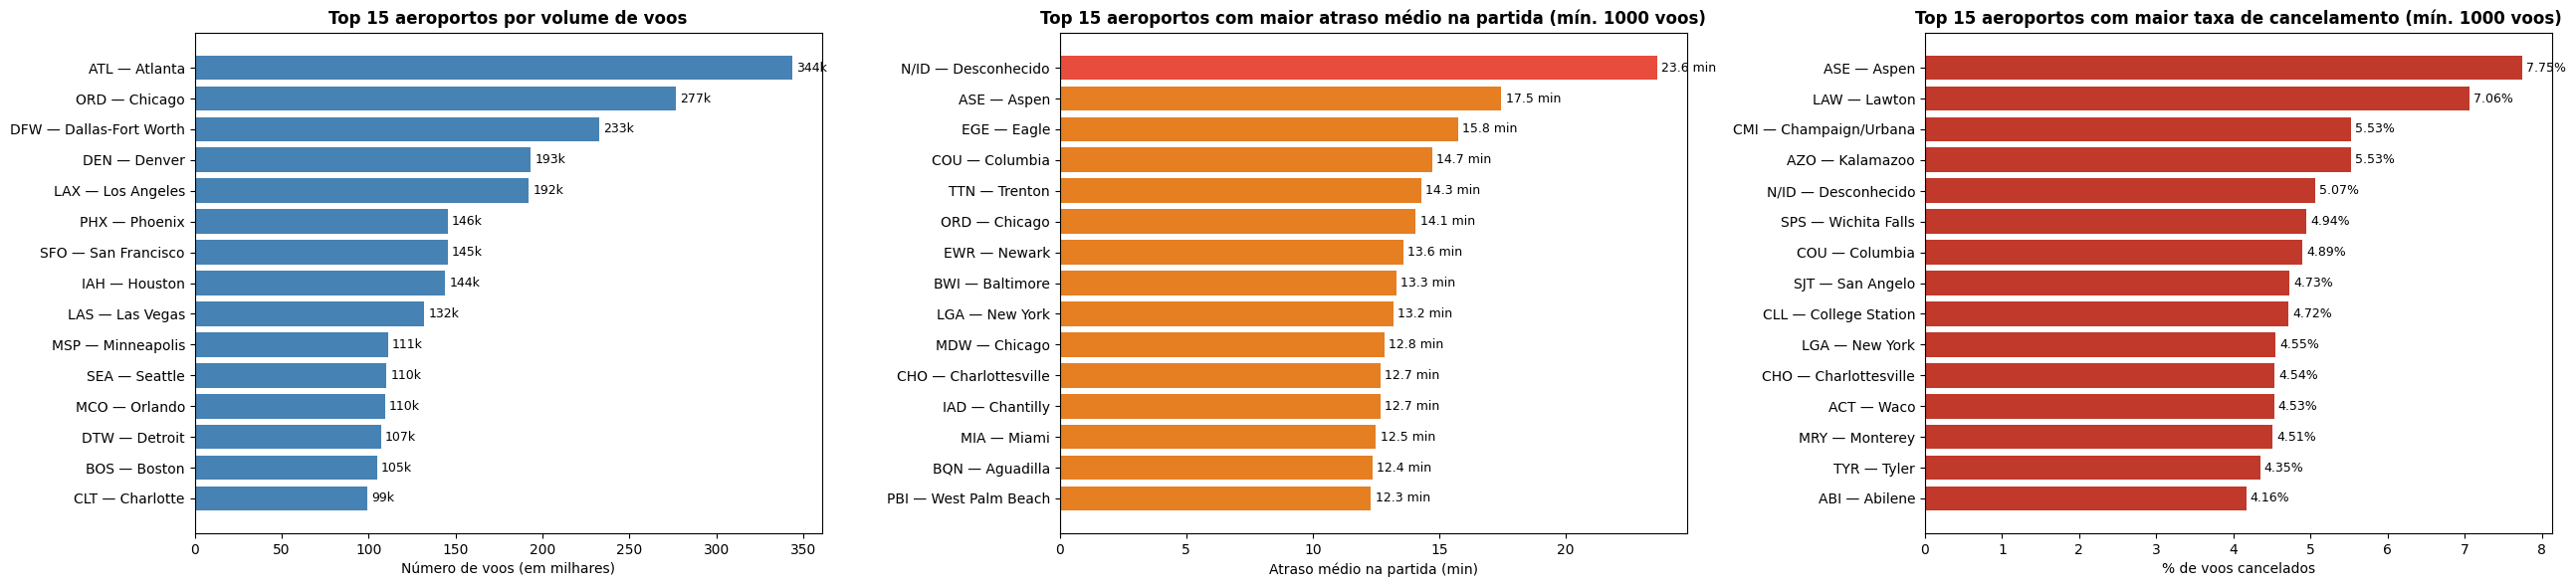

In [76]:
airport_cancel = (
    flights.groupby('ORIGIN_AIRPORT')['CANCELLED']
    .agg(total_all='count', total_cancelled='sum')
    .assign(pct_cancelled=lambda df: df['total_cancelled'] / df['total_all'] * 100)
    .reset_index()
)

airport_stats = (
    completed
    .groupby('ORIGIN_AIRPORT')
    .agg(
        total_flights=('ARRIVAL_DELAY', 'count'),
        avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
    )
    .reset_index()
    .merge(airport_cancel, on='ORIGIN_AIRPORT', how='left')
    .merge(airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']],
           left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
)

# Preenche aeroportos sem match (codigos numericos FAA sem IATA)
airport_stats['IATA_CODE']  = airport_stats['IATA_CODE'].fillna('N/ID')
airport_stats['AIRPORT']    = airport_stats['AIRPORT'].fillna('Aeroporto não identificado')
airport_stats['CITY']       = airport_stats['CITY'].fillna('Desconhecido')
airport_stats['STATE']      = airport_stats['STATE'].fillna('--')

# Top 15 mais movimentados
top_volume = airport_stats.nlargest(15, 'total_flights')
# Top 15 com mais atraso (mín. 1000 voos)
top_delay  = airport_stats[airport_stats['total_flights'] >= 1000].nlargest(15, 'avg_departure_delay')
# Top 15 com mais cancelamentos (mín. 1000 voos)
top_cancel = airport_stats[airport_stats['total_all'] >= 1000].nlargest(15, 'pct_cancelled')

fig, axes = plt.subplots(1, 3, figsize=(26, 6))

ax = axes[0]
label = top_volume.apply(lambda r: f"{r['IATA_CODE']} — {r['CITY']}", axis=1)
bars = ax.barh(label, top_volume['total_flights'] / 1000, color='steelblue')
ax.bar_label(bars, fmt='%.0fk', padding=3, fontsize=9)
ax.set_xlabel('Número de voos (em milhares)')
ax.set_title('Top 15 aeroportos por volume de voos', fontweight='bold')
ax.invert_yaxis()

ax = axes[1]
label2 = top_delay.apply(lambda r: f"{r['IATA_CODE']} — {r['CITY']}", axis=1)
palette = ['#e74c3c' if v > 20 else '#e67e22' for v in top_delay['avg_departure_delay']]
bars = ax.barh(label2, top_delay['avg_departure_delay'], color=palette)
ax.bar_label(bars, fmt='%.1f min', padding=3, fontsize=9)
ax.set_xlabel('Atraso médio na partida (min)')
ax.set_title('Top 15 aeroportos com maior atraso médio na partida (mín. 1000 voos)', fontweight='bold')
ax.invert_yaxis()

ax = axes[2]
label3 = top_cancel.apply(lambda r: f"{r['IATA_CODE']} — {r['CITY']}", axis=1)
bars = ax.barh(label3, top_cancel['pct_cancelled'], color='#c0392b')
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_xlabel('% de voos cancelados')
ax.set_title('Top 15 aeroportos com maior taxa de cancelamento (mín. 1000 voos)', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()


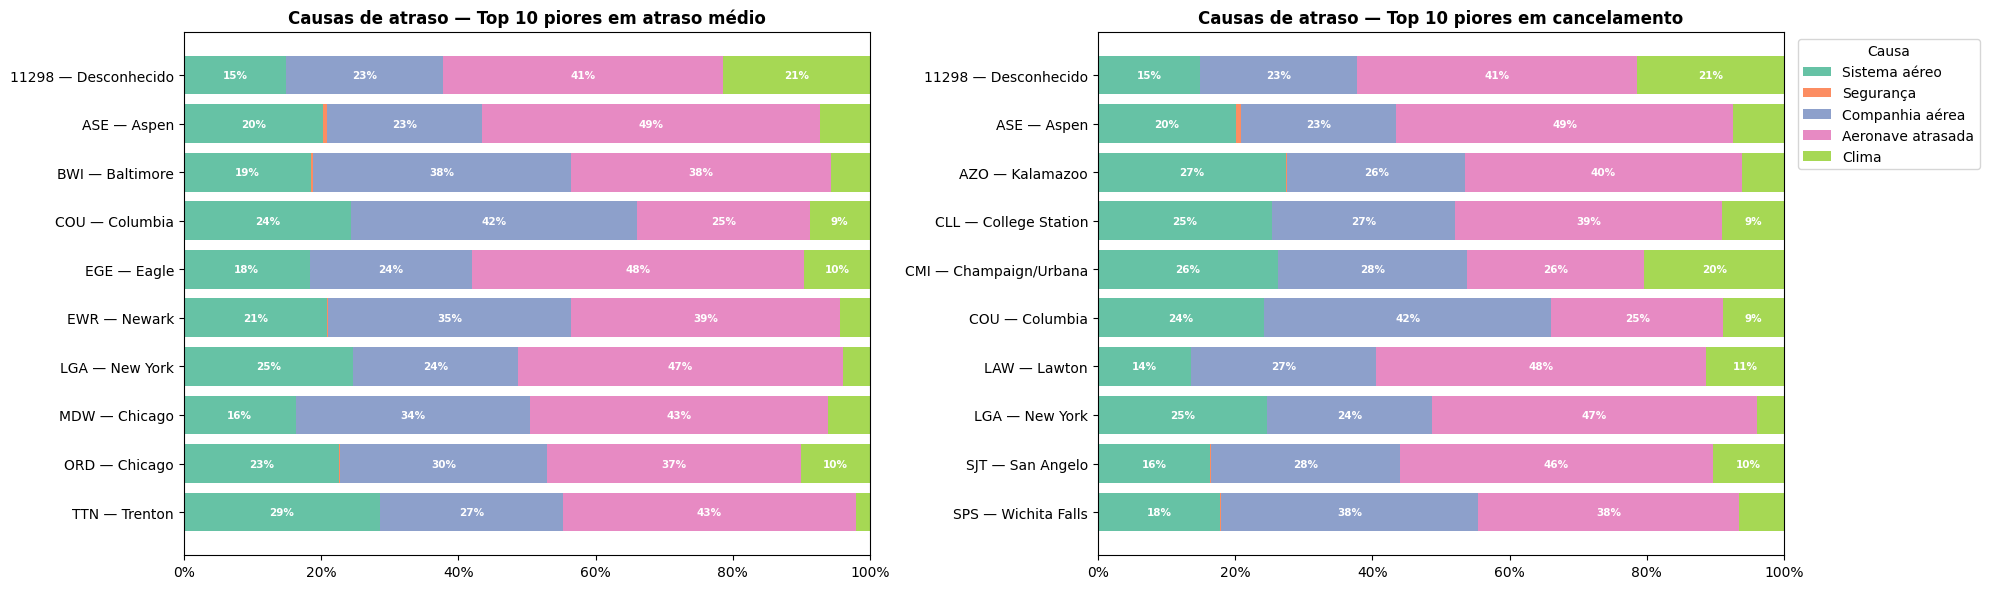

In [77]:
# Motivos de atraso para os 10 piores em atraso e em cancelamento
delay_cause_cols = ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
cause_labels     = ['Sistema aéreo','Segurança','Companhia aérea','Aeronave atrasada','Clima']
completed[delay_cause_cols] = completed[delay_cause_cols].fillna(0)

top10_delay_codes  = airport_stats[airport_stats['total_flights'] >= 1000].nlargest(10, 'avg_departure_delay')['ORIGIN_AIRPORT'].tolist()
top10_cancel_codes = airport_stats[airport_stats['total_all']    >= 1000].nlargest(10, 'pct_cancelled')['ORIGIN_AIRPORT'].tolist()

def cause_pct_by_airport(codes):
    sub = completed[completed['ORIGIN_AIRPORT'].isin(codes)]
    sub = sub[sub[delay_cause_cols].sum(axis=1) > 0]
    pct = (
        sub.groupby('ORIGIN_AIRPORT')[delay_cause_cols].sum()
        .rename(columns=dict(zip(delay_cause_cols, cause_labels)))
    )
    pct = pct.div(pct.sum(axis=1), axis=0) * 100
    pct = pct.merge(airports[['IATA_CODE','CITY']], left_index=True, right_on='IATA_CODE', how='left')
    pct['IATA_CODE'] = pct['IATA_CODE'].fillna('N/ID')
    pct['CITY']      = pct['CITY'].fillna('Desconhecido')
    pct['label']     = pct['IATA_CODE'] + ' — ' + pct['CITY']
    return pct.set_index('label')[cause_labels]

pct_delay  = cause_pct_by_airport(top10_delay_codes)
pct_cancel = cause_pct_by_airport(top10_cancel_codes)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
colors = sns.color_palette('Set2', len(cause_labels))

for ax, pct, title in zip(axes,
                          [pct_delay, pct_cancel],
                          ['Causas de atraso — Top 10 piores em atraso médio',
                           'Causas de atraso — Top 10 piores em cancelamento']):
    bottom = pd.Series([0.0] * len(pct), index=pct.index)
    for col, color in zip(cause_labels, colors):
        bars = ax.barh(pct.index, pct[col], left=bottom, label=col, color=color)
        for bar, val, bot in zip(bars, pct[col], bottom):
            if val >= 8:
                ax.text(bot + val / 2, bar.get_y() + bar.get_height() / 2,
                        f'{val:.0f}%', ha='center', va='center', fontsize=7.5,
                        fontweight='bold', color='white')
        bottom += pct[col]
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()

axes[1].legend(title='Causa', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observações - Aeroportos mais movimentados, com maiores atrasos e cancelamentos:**

**Volume:**
- **ATL (Atlanta)** lidera com 343k voos e bom desempenho: 0.74% de cancelamentos e 9.3 min de atraso.
- **ORD (Chicago, 276k)** é o pior grande hub em ambas as métricas: 2.99% de cancelamentos e 14.1 min de atraso. Os motivos revelam uma combinação de aeronave atrasada e companhia aérea.

**Causas nos piores em atraso:**
- **Aeronave atrasada domina** na maioria dos piores aeroportos em atraso: ASE (49.2%), CHO (46.4%), LGA (47.5%), EGE (48.4%). O efeito cascata de aeronaves sem folga é o principal vetor de atraso nesses aeroportos.
- **ASE (Aspen) e EGE (Eagle)** tem perfil misto: aeronave atrasada (49%) combinada com clima relevante (>7%) .
- **COU (Columbia)** companhia aérea é a causa principal (41.7%), sugerindo problemas operacionais internos mais do que pressão de malha.
- **TTN (Trenton)** tem a maior participação de sistema aéreo (28.5%) do grupo.

**Causas nos piores em cancelamento:**
- **CMI (Champaign/Urbana)** é o único aeroporto com clima como segunda causa mais relevante (20.3%).
- **Aeronave atrasada também domina** nos piores em cancelamento: LAW (48.2%), ASE (49.2%), SJT (45.5%), CHO (46.4%). O que sugere que os cancelamentos nesses aeroportos podem resultar de aeronaves que não chegam a tempo para operar o voo.
- **LGA (New York)** aparece nos dois rankings negativos com o mesmo perfil: aeronave atrasada (47.5%) e sistema aéreo (24.7%).
- **ASE (Aspen)** está presente nos dois rankings com o mesmo perfil de causas.

---
## 11. Distância × Atraso

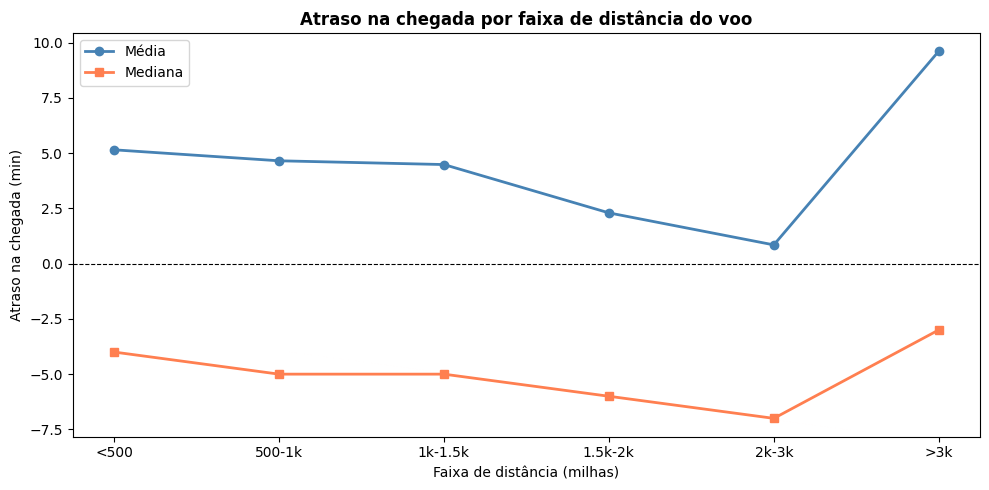

,mean,median,count
DIST_BIN,,,
<500,5.147220,-4.0,2087046
500-1k,4.650499,-5.0,2002895
1k-1.5k,4.480513,-5.0,846699
1.5k-2k,2.294989,-6.0,407741
2k-3k,0.846202,-7.0,360173
>3k,9.607574,-3.0,9454


In [78]:
# Atraso médio por faixa de distância
completed['DIST_BIN'] = pd.cut(
    completed['DISTANCE'],
    bins=[0, 500, 1000, 1500, 2000, 3000, 6000],
    labels=['<500', '500-1k', '1k-1.5k', '1.5k-2k', '2k-3k', '>3k']
)

dist_delay = (
    completed
    .groupby('DIST_BIN', observed=True)['ARRIVAL_DELAY']
    .agg(['mean', 'median', 'count'])
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dist_delay.index.astype(str), dist_delay['mean'], marker='o',
        label='Média', color='steelblue', lw=2)
ax.plot(dist_delay.index.astype(str), dist_delay['median'], marker='s',
        label='Mediana', color='coral', lw=2)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Faixa de distância (milhas)')
ax.set_ylabel('Atraso na chegada (min)')
ax.set_title('Atraso na chegada por faixa de distância do voo', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

dist_delay

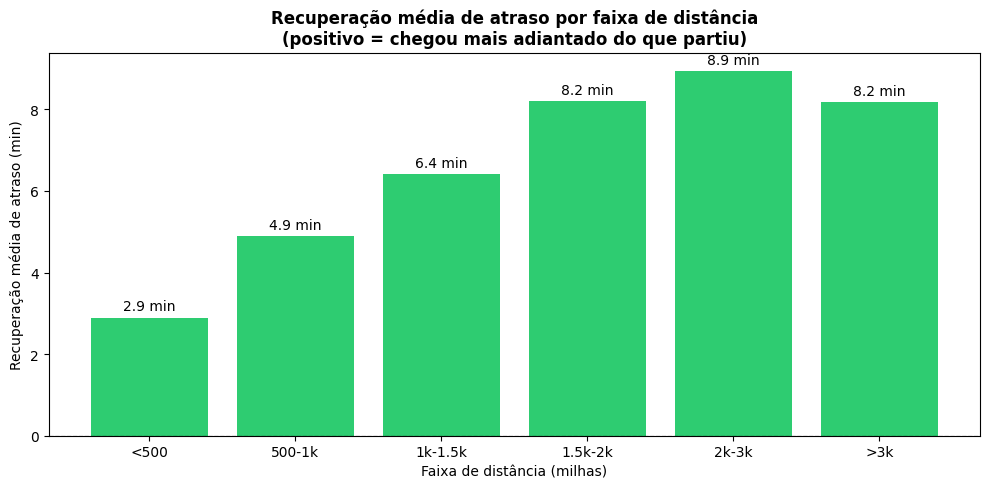

In [79]:
# Recuperação média de atraso por faixa de distância
completed['DELAY_RECOVERED'] = completed['DEPARTURE_DELAY'] - completed['ARRIVAL_DELAY']

dist_recovery = (
    completed
    .groupby('DIST_BIN', observed=True)['DELAY_RECOVERED']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in dist_recovery['DELAY_RECOVERED']]
bars = ax.bar(dist_recovery['DIST_BIN'].astype(str), dist_recovery['DELAY_RECOVERED'], color=colors)
ax.bar_label(bars, fmt='%.1f min', padding=3, fontsize=10)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Faixa de distância (milhas)')
ax.set_ylabel('Recuperação média de atraso (min)')
ax.set_title('Recuperação média de atraso por faixa de distância\n(positivo = chegou mais adiantado do que partiu)', fontweight='bold')
plt.tight_layout()
plt.show()


**Observações - Distância × Atraso:**

- **Voos curtos (<500 mi) têm o maior atraso médio na chegada (5.1 min)**, seguidos de perto pelos de 500–1k mi (4.6 min). Isso parece contraintuitivo, mas faz sentido: rotas curtas têm menos tempo de voo disponível para compensar atrasos na partida e qualquer imprevisto no solo se traduz diretamente em atraso na chegada.
- **A mediana é negativa em todas as faixas** (-3 a -7 min), indicando que a maioria dos voos chega antes do horário previsto. O atraso médio positivo é puxado por uma minoria de voos com atrasos severos. É uma distribuição assimétrica à direita típica de dados de atraso.
- **Voos de 2k–3k mi têm o menor atraso médio (0.9 min):** faixas de longa distância permitem maior recuperação durante o voo: atrasos na partida são parcialmente compensados pela flexibilidade de velocidade e rota.
- A recuperação média de atraso (diferença entre atraso na partida e na chegada) cresce consistentemente com a distância: voos **<500 mi recuperam apenas 2.9 min**, enquanto voos **2k–3k mi recuperam 8.9 min** em média, confirmando que distância é o principal fator de absorção de atrasos.
- **Voos >3k mi são uma exceção**: atraso médio sobe para 9.6 min com volume muito baixo (9.4k voos, <0.2% do total). Provavelmente são rotas específicas com menos redundância e frequência.

---
## 12. Correlação entre variáveis numéricas

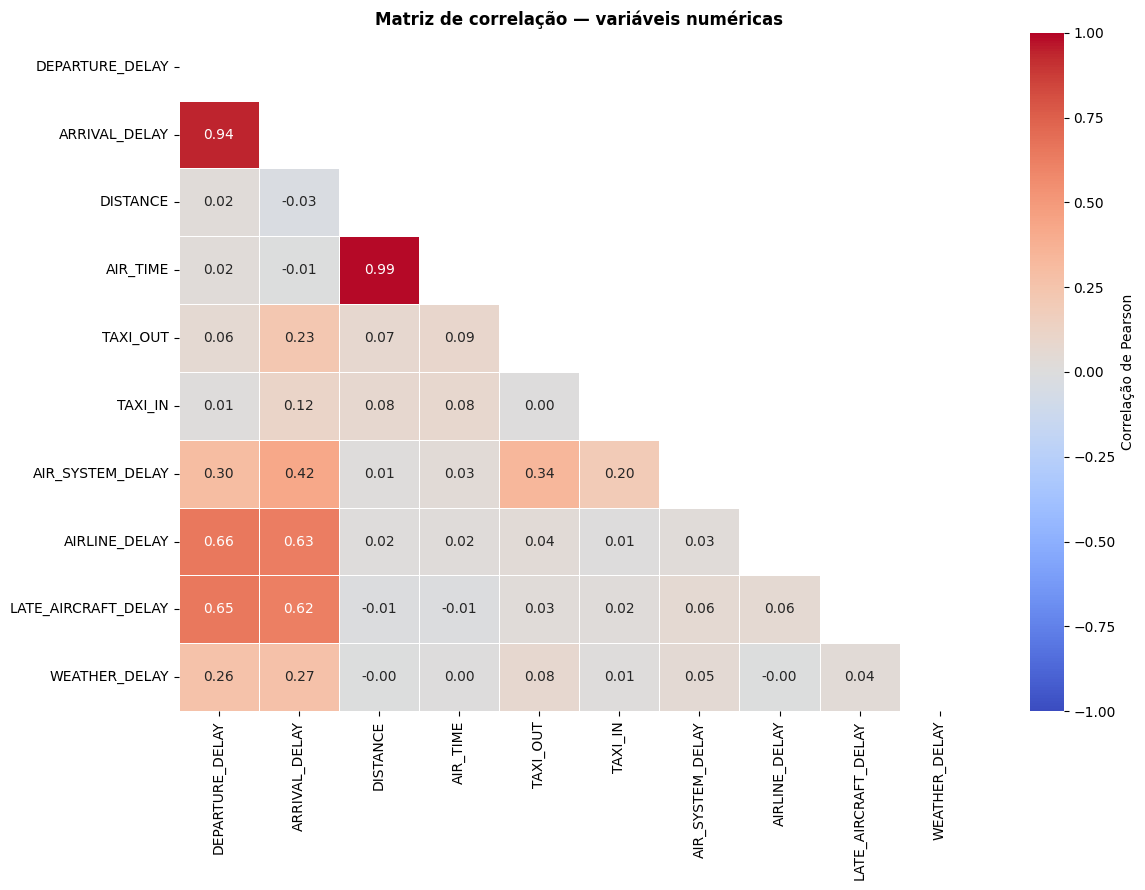

In [80]:
corr_cols = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE',
    'AIR_TIME', 'TAXI_OUT', 'TAXI_IN',
    'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

corr_matrix = completed[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlação de Pearson'})
ax.set_title('Matriz de correlação — variáveis numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

**Observações - Correlação entre variáveis numéricas:**

- **DISTANCE × AIR_TIME (0.99)**: correlação quase perfeita, esperada: tempo de voo é diretamente proporcional à distância. Confirma consistência dos dados.
- **DEPARTURE_DELAY × ARRIVAL_DELAY (0.94)**: correlação muito forte, reforçando o que foi observado nas seções anteriores: atrasos na partida raramente são recuperados durante o voo. O atraso na partida é o melhor preditor isolado do atraso na chegada.
- **DEPARTURE_DELAY × AIRLINE_DELAY (0.62)** e **× LATE_AIRCRAFT_DELAY (0.55)**: as causas de maior correlação com o atraso na partida são internas às companhias aéreas (decisões operacionais e aeronaves atrasadas), não fatores externos como clima ou sistema aéreo.
- **TAXI_OUT × AIR_SYSTEM_DELAY (0.36)**: tempo de táxi na saída tem correlação moderada com atrasos do sistema aéreo, esperado: congestionamento no solo e na pista é reflexo direto da saturação do espaço aéreo.
- **Clima e sistema aéreo têm correlações fracas com os atrasos totais** (0.24–0.26): apesar de serem causas relevantes em eventos específicos, seu impacto no atraso médio geral é diluído pela baixa frequência relativa frente a causas operacionais.
- **AIR_SYSTEM_DELAY × LATE_AIRCRAFT_DELAY (-0.15)** possui leve correlação negativa: quando o sistema aéreo está congestionado, aeronaves tendem a ter menos atrasos próprios acumulados.